<a href="https://colab.research.google.com/github/srj1407/Data_Science_and_ML/blob/main/PyTorch_Computer_Vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

print(f'Torch version:{torch.__version__} | Torchvision version: {torchvision.__version__}')

Torch version:2.11.0+cu128 | Torchvision version: 0.26.0+cu128


In [5]:
train_data = datasets.FashionMNIST(
    root = 'datasets',
    train = True,
    transform = ToTensor(),
    download = True,
    target_transform = None
)

test_data = datasets.FashionMNIST(
    root = 'datasets',
    train = False,
    transform = ToTensor(),
    download = True
)

In [6]:
image, label = train_data[59000]

In [7]:
image

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0157, 0.0000, 0.1843, 0.4314, 0.4392, 0.0078,
          0.0000, 0.0078, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0039, 0.0000, 0.0000, 0.6039, 0.0000, 0.1020, 0.6902,
          0.0000, 0.0039, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0157, 0.0000, 0.2275, 0.3686, 0.0000, 0.0000, 0.6667,
          0.2000, 0.0000, 0.0196, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0196, 0.0000, 0.5059, 0.1451, 0.0000, 0.0000, 0.5333,
          0.5059, 0.0000, 0.0235, 0.0000, 0.0000, 0.0000,

In [8]:
label

8

In [9]:
image.shape

torch.Size([1, 28, 28])

In [10]:
train_data.data.shape

torch.Size([60000, 28, 28])

In [11]:
train_data.targets.shape

torch.Size([60000])

In [12]:
test_data.data.shape

torch.Size([10000, 28, 28])

In [13]:
test_data.targets.shape

torch.Size([10000])

In [14]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

Image shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, '8')

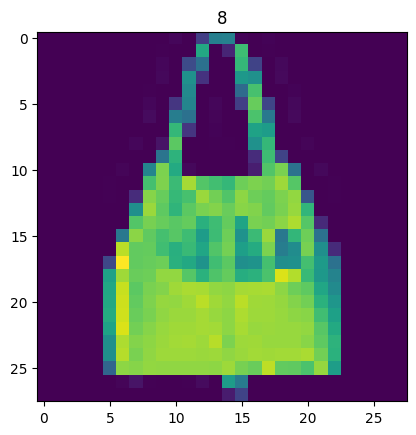

In [15]:
import matplotlib.pyplot as plt
image, label = train_data[59000]
print(f'Image shape: {image.shape}')
plt.imshow(image.squeeze())
plt.title(label)

Text(0.5, 1.0, 'Bag')

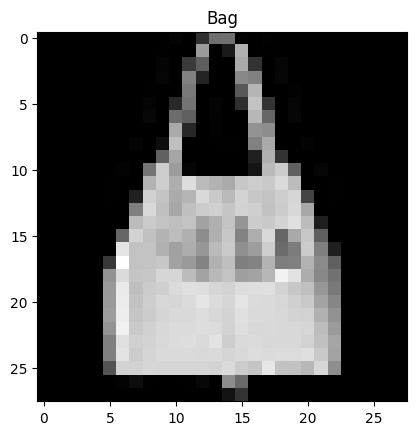

In [16]:
plt.imshow(image.squeeze(), cmap = 'grey')
plt.title(class_names[label])

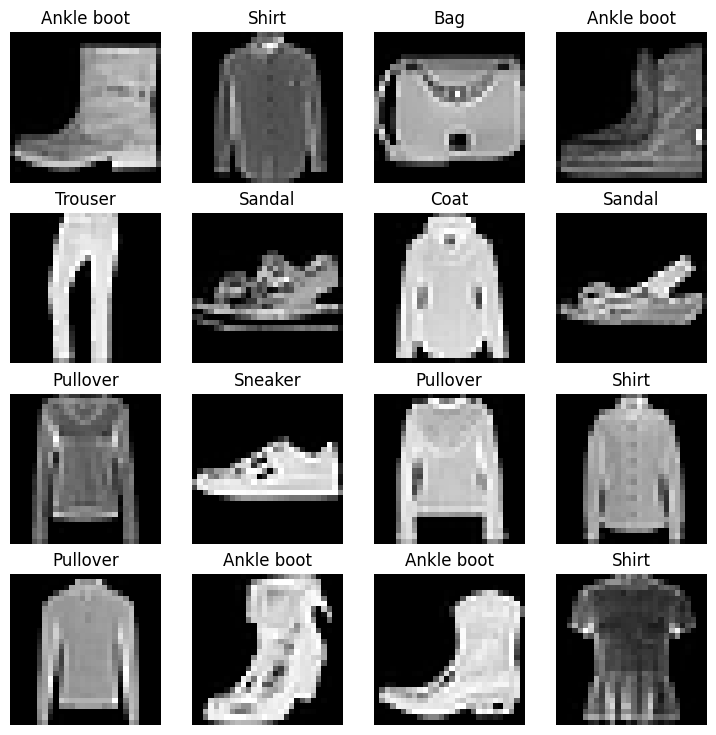

In [17]:
torch.manual_seed(42)
fig = plt.figure(figsize = (9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
  random_idx = torch.randint(0, len(train_data), size = [1]).item()
  img, label = train_data[random_idx]
  fig.add_subplot(rows, cols, i)
  plt.imshow(img.squeeze(), cmap = 'grey')
  plt.title(class_names[label])
  plt.axis(False)

In [18]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(
    train_data,
    batch_size = BATCH_SIZE,
    shuffle = True
)

test_dataloader = DataLoader(
    test_data,
    batch_size = BATCH_SIZE,
    shuffle = False
)

In [19]:
train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7c4aefb94530>,
 <torch.utils.data.dataloader.DataLoader at 0x7c4aefa0c4a0>)

In [20]:
len(train_dataloader), len(test_dataloader)

(1875, 313)

In [21]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch, train_labels_batch

(tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0157, 0.0000, 0.0039],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],
 
 
         [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],
 
 
         [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000

In [22]:
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [23]:
train_features_batch[0].shape

torch.Size([1, 28, 28])

In [24]:
1875 * 32

60000

Image size: torch.Size([1, 28, 28])
Label: 6, Label size: torch.Size([])


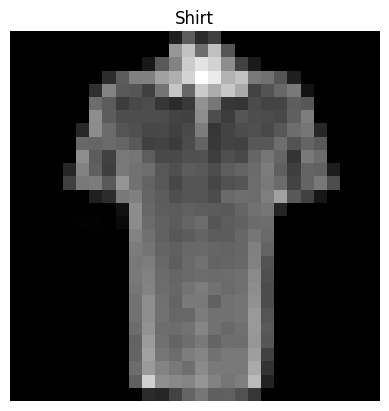

In [25]:
torch.manual_seed(42)

random_idx = torch.randint(0, len(train_features_batch), size = [1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap = 'gray')
plt.title(class_names[label])
plt.axis('Off')
print(f'Image size: {img.shape}')
print(f'Label: {label}, Label size: {label.shape}')


In [26]:
flatten_model = nn.Flatten()
x = train_features_batch[0]
output = flatten_model(x)
x.shape, output.shape

(torch.Size([1, 28, 28]), torch.Size([1, 784]))

In [27]:
from torch import nn

class FashionMNISTModelV0(nn.Module):
  def __init__(self, input_shape: int, hidden_shape: int, output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = input_shape, out_features = hidden_shape),
        nn.Linear(in_features = hidden_shape, out_features = output_shape)
    )

  def forward(self, x):
      return self.layer_stack(x)

In [28]:
torch.manual_seed(42)

model_0 = FashionMNISTModelV0(
    input_shape = 784,
    hidden_shape = 10,
    output_shape = len(class_names)
)

model_0.to('cpu')

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [29]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  # Note: you need the "raw" GitHub URL for this to work
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

helper_functions.py already exists, skipping download


In [30]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_0.parameters(), lr = 0.1)

In [31]:
from timeit import default_timer as timer

def print_train_time(start: float, end: float, device: torch.device = None):
  total_time = end - start
  print(f'Total train time: {total_time:.3f} on device: {device}')
  return total_time

In [32]:
from tqdm.auto import tqdm

torch.manual_seed(42)
train_start_time_on_cpu = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
  print(f'Epoch: {epoch}\n------')
  train_loss = 0

  for batch, (X, y) in enumerate(train_dataloader):
    model_0.train()
    y_train_pred = model_0(X)
    loss = loss_fn(y_train_pred, y)
    train_loss += loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if batch % 400 == 0:
      print(f'Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples')
  train_loss /= len(train_dataloader)

  test_loss, test_acc = 0, 0
  model_0.eval()
  with torch.inference_mode():
    for X, y in test_dataloader:
      y_test_pred = model_0(X)
      test_loss += loss_fn(y_test_pred, y)
      test_acc += accuracy_fn(y, y_test_pred.argmax(dim = 1))
    test_loss = test_loss / len(test_dataloader)
    test_acc = test_acc / len(test_dataloader)

  print(f'Train Loss: {train_loss:.5f} | Test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%\n')

  train_time_end_on_cpu = timer()
  total_train_time_model_0 = print_train_time(train_start_time_on_cpu, train_time_end_on_cpu, str(next(model_0.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train Loss: 0.59039 | Test Loss: 0.50954 | Test Accuracy: 82.04%

Total train time: 9.955 on device: cpu
Epoch: 1
------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train Loss: 0.47633 | Test Loss: 0.47989 | Test Accuracy: 83.20%

Total train time: 19.909 on device: cpu
Epoch: 2
------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train Loss: 0.45503 | Test Loss: 0.47664 | Test Accuracy: 83.43%

Total train time: 30.060 on device: cpu


In [33]:
torch.manual_seed(42)
def eval_model(model: nn.Module,
         data_loader: torch.utils.data.DataLoader,
         loss_fn: loss_fn,
         acc_fn: accuracy_fn):
  loss, acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X, y in data_loader:
      pred = model(X)
      loss += loss_fn(pred, y)
      acc += acc_fn(y, pred.argmax(dim = 1))
    loss = loss / len(data_loader)
    acc = acc / len(data_loader)

  return {
      'Model Name': model.__class__.__name__,
      'Loss': loss.item(),
      'Accuracy': acc
  }

model_0_results = eval_model(model_0, test_dataloader, loss_fn, accuracy_fn)
model_0_results

{'Model Name': 'FashionMNISTModelV0',
 'Loss': 0.47663888335227966,
 'Accuracy': 83.42651757188499}

In [34]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [35]:
class FashionMNISTModelV1(nn.Module):
  def __init__(self, input_features, hidden_features, output_features):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = input_features, out_features = hidden_features),
        nn.ReLU(),
        nn.Linear(in_features = hidden_features, out_features = output_features),
        nn.ReLU()
    )
  def forward(self, X: torch.Tensor):
    return self.layer_stack(X)

In [36]:
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(input_features = 784, hidden_features = 10, output_features = len(class_names)).to(device)
next(model_1.parameters()).device


device(type='cuda', index=0)

In [37]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_1.parameters(), lr = 0.1)

In [38]:
def train_step(
    model: torch.nn.Module,
    data_loader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    accuracy_fn,
    device: torch.device = device
):
  train_loss, train_acc = 0, 0
  model.to(device)
  for batch, (X, y) in enumerate(data_loader):
    X, y = X.to(device), y.to(device)
    print(f'X.shape: {X.shape}')
    y_pred = model(X)
    loss = loss_fn(y_pred, y)
    train_loss += loss
    train_acc += accuracy_fn(y, y_pred.argmax(dim = 1))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  print(f'Train Loss: {train_loss:.5f} | Train Accuracy: {train_acc:.2f}%')

def test_step(
    model: torch.nn.Module,
    data_loader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    accuracy_fn,
    device: torch.device = device
):
  test_loss, test_acc = 0, 0
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for (X, y) in data_loader:
      X, y = X.to(device), y.to(device)
      y_pred = model(X)
      test_loss += loss_fn(y_pred, y)
      test_acc += accuracy_fn(y_true = y, y_pred = y_pred.argmax(dim = 1))
    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
    print(f'Test Loss: {test_loss} | Test Accuracy: {test_acc}')

In [39]:
from timeit import default_timer as timer

torch.manual_seed(42)

train_time_start_on_gpu = timer()

epochs = 3

for epoch in range(epochs):
  print(f'Epoch: {epoch}\n-----')
  train_step(model = model_1, data_loader = train_dataloader, loss_fn = loss_fn, optimizer = optimizer, accuracy_fn = accuracy_fn)
  test_step(model = model_1, data_loader = test_dataloader, loss_fn = loss_fn, accuracy_fn = accuracy_fn, device = device)
train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(train_start_time_on_cpu, train_time_end_on_cpu, device)


Streaming output truncated to the last 5000 lines.
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32,

In [40]:
torch.manual_seed(42)

model_1_results = eval_model(model = model_1, data_loader = test_dataloader, loss_fn = loss_fn, acc_fn = accuracy_fn)

model_1_results

RuntimeError: Expected all tensors to be on the same device, but got mat1 is on cpu, different from other tensors on cuda:0 (when checking argument in method wrapper_CUDA_addmm)

In [ ]:
torch.manual_seed(42)
def eval_model(model: nn.Module,
         data_loader: torch.utils.data.DataLoader,
         loss_fn: loss_fn,
         acc_fn: accuracy_fn):
  loss, acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X, y in data_loader:
      X, y = X.to(device), y.to(device)
      pred = model(X)
      loss += loss_fn(pred, y)
      acc += acc_fn(y, pred.argmax(dim = 1))
    loss = loss / len(data_loader)
    acc = acc / len(data_loader)

  return {
      'Model Name': model.__class__.__name__,
      'Loss': loss.item(),
      'Accuracy': acc
  }

model_1_results = eval_model(model = model_1, data_loader = test_dataloader, loss_fn = loss_fn, acc_fn = accuracy_fn)

model_1_results


In [ ]:
model_0_results

In [ ]:
class FashionMNISTModelV2(nn.Module):
  def __init__(self, input_features, hidden_features, output_features):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = input_features, out_features = hidden_features),
        nn.ReLU(),
        nn.Linear(in_features = hidden_features, out_features = output_features),
    )
  def forward(self, X: torch.Tensor):
    return self.layer_stack(X)

In [ ]:
torch.manual_seed(42)
model_2 = FashionMNISTModelV1(input_features = 784, hidden_features = 5, output_features = len(class_names)).to(device)
next(model_2.parameters()).device


In [ ]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_2.parameters(), lr = 0.1)

In [ ]:
from timeit import default_timer as timer

torch.manual_seed(42)

train_time_start_on_gpu = timer()

epochs = 3

for epoch in range(epochs):
  print(f'Epoch: {epoch}\n-----')
  train_step(model = model_2, data_loader = train_dataloader, loss_fn = loss_fn, optimizer = optimizer, accuracy_fn = accuracy_fn)
  test_step(model = model_2, data_loader = test_dataloader, loss_fn = loss_fn, accuracy_fn = accuracy_fn, device = device)
train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(train_start_time_on_cpu, train_time_end_on_cpu, device)


In [ ]:
torch.manual_seed(42)

model_2_results = eval_model(model = model_2, data_loader = test_dataloader, loss_fn = loss_fn, acc_fn = accuracy_fn)

model_2_results

In [41]:
class FashionMNISTModelV3(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.block_1 = nn.Sequential(
        nn.Conv2d(
            in_channels = input_shape,
            out_channels = hidden_units,
            kernel_size = 3,
            padding = 1,
            stride = 1
        ),
        nn.ReLU(),
        nn.Conv2d(
            in_channels = hidden_units,
            out_channels = hidden_units,
            kernel_size = 3,
            stride = 1,
            padding = 1
        ),
        nn.ReLU(),
        nn.MaxPool2d(
            kernel_size = 2,
            stride = 2
        )
    )
    self.block_2 = nn.Sequential(
        nn.Conv2d(hidden_units, hidden_units, 3, padding = 1),
        nn.ReLU(),
        nn.Conv2d(hidden_units, hidden_units, 3, padding = 1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = hidden_units * 7 * 7, out_features = output_shape)
    )
  def forward(self, x):
    x = self.block_1(x)
    # print(f'After block 1: {x.shape}')
    x = self.block_2(x)
    # print(f'After block 2: {x.shape}')
    x = self.classifier(x)
    # print(f'After block 3: {x.shape}')
    return x

torch.manual_seed(42)
model_3 = FashionMNISTModelV3(input_shape = 1, hidden_units = 10, output_shape = len(class_names)).to(device)
model_3

FashionMNISTModelV3(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [ ]:
torch.manual_seed(42)

images = torch.randn(size = (32, 3, 64, 64))
test_image = images[0]
images.shape, test_image.shape, test_image

In [ ]:
torch.manual_seed(42)
conv_layer = nn.Conv2d(
    in_channels = 3,
    out_channels = 10,
    kernel_size = 3,
    stride = 1,
    padding = 0
)
layer_result = conv_layer(test_image)
layer_result.shape

In [ ]:
torch.manual_seed(42)
conv_layer = nn.Conv2d(
    in_channels = 3,
    out_channels = 10,
    kernel_size = 2,
    stride = 1
)
layer_result = conv_layer(test_image)
layer_result.shape

In [ ]:
conv_layer.weight.shape, conv_layer.bias.shape

In [ ]:
max_pool = nn.MaxPool2d(kernel_size = 2)
layer_result_2 = max_pool(layer_result)
layer_result_2.shape

In [42]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_3.parameters(), lr = 0.1)

In [ ]:
train_data, train_data_labels = next(iter(train_dataloader))

In [ ]:
train_data.shape

In [ ]:
train_data_labels.shape

In [ ]:
test_data, test_data_labels = next(iter(test_dataloader))
test_data.shape, test_data_labels.shape

In [43]:
from timeit import default_timer as timer
torch.manual_seed(42)

train_time_start_model_3 = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
  print(f'Epoch: {epoch}\n-------------')
  train_step(
      model = model_3,
      data_loader = train_dataloader,
      loss_fn = loss_fn,
      optimizer = optimizer,
      accuracy_fn = accuracy_fn,
      device = device
  )
  test_step(
      model = model_3,
      data_loader = test_dataloader,
      accuracy_fn = accuracy_fn,
      device = device,
      loss_fn = loss_fn
  )

  train_time_end_model_3 = timer()

  total_train_time_model_3 = print_train_time(
      start = train_time_start_model_3, end = train_time_end_model_3, device = device
  )


  0%|          | 0/3 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32, 1, 28, 28])
X.shape: torch.Size([32,

In [ ]:
model_3_results = eval_model(
    model = model_3, data_loader = test_dataloader, loss_fn = loss_fn, acc_fn = accuracy_fn
)
model_3_results


In [ ]:
len(next(iter(test_dataloader)))

In [ ]:
next(iter(test_dataloader))[0].shape

In [ ]:
next(iter(test_dataloader))[1].shape

Train dataloader -> List of 1875 items. Each item has a 2 things. First is a batch of 32 data points of shape (1, 28, 28) and second is a batch of the labels of those 32 data points. Each data point is an image of shape (1, 28, 28) where 1 represents it is a black and white image and 28*28 is the shape of that image.

In [ ]:
next(model_3.parameters()).device

In [ ]:
sample = next(iter(test_dataloader))[0].to(device)

In [ ]:
next(iter(test_dataloader))[1]

In [ ]:
sample[1].shape

In [ ]:
logit = model_3(sample[1].unsqueeze(dim = 0))
logit

In [ ]:
def make_predictions(model: torch.nn.Module, data: list, device: torch.device = device):
  pred_probs = []
  model.eval()
  with torch.inference_mode():
    for sample in data:
      sample = torch.unsqueeze(sample, dim = 0).to(device)
      pred_logit = model(sample)
      pred_prob = torch.softmax(pred_logit.squeeze(), dim = 0)
      pred_probs.append(pred_prob.cpu())
  return torch.stack(pred_probs)

In [ ]:
test_data[0]

In [ ]:
test_data.data.shape

In [ ]:
test_data.targets.shape

In [ ]:
test_data.classes

In [ ]:
import random
random.seed(42)

test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k = 9):
  test_samples.append(sample)
  test_labels.append(label)

test_samples[0].shape

In [ ]:
pred_probs = make_predictions(model = model_3, data = test_samples)
pred_probs[:2]

In [ ]:
pred_classes = pred_probs.argmax(dim = 1)
pred_classes

In [ ]:
test_labels

In [ ]:
try:
  import torchmetrics, mlxtend
except ImportError as e:
  print(f"Caught ImportError: {e}. Reinstalling numpy, scipy, torchmetrics, and mlxtend with a compatible numpy version...")
  # Uninstall relevant packages first to ensure a clean install
  !pip uninstall -y numpy scipy torchmetrics mlxtend
  # Install a specific, compatible version of numpy, then other packages
  !pip install numpy==1.26.4 scipy torchmetrics mlxtend
  # Try importing again after reinstallation
  import torchmetrics, mlxtend
print(f'torchmetrics version: {torchmetrics.__version__}')
print(f'mlxtend version: {mlxtend.__version__}')

In [46]:
# Import tqdm for progress bar
from tqdm.auto import tqdm

# 1. Make predictions with trained model
y_preds = []
model_3.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making predictions"):
    # Send data and targets to target device
    X, y = X.to(device), y.to(device)
    # Do the forward pass
    y_logit = model_3(X)
    # Turn predictions from logits -> prediction probabilities -> predictions labels
    y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1) # note: perform softmax on the "logits" dimension, not "batch" dimension (in this case we have a batch size of 32, so can perform on dim=1)
    # Put predictions on CPU for evaluation
    y_preds.append(y_pred.cpu())
# Concatenate list of predictions into a tensor
y_pred_tensor = torch.cat(y_preds)

Making predictions:   0%|          | 0/313 [00:00<?, ?it/s]

In [47]:
len(y_preds)

313

In [48]:
y_preds

[tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 5, 3, 4, 1, 2, 2, 8, 0, 2, 7, 7, 5,
         1, 6, 6, 0, 9, 4, 8, 8]),
 tensor([3, 3, 8, 0, 7, 5, 7, 9, 0, 1, 0, 7, 6, 7, 2, 1, 4, 6, 4, 4, 5, 8, 2, 2,
         8, 4, 8, 0, 7, 7, 8, 5]),
 tensor([1, 1, 4, 4, 7, 8, 7, 0, 2, 6, 2, 3, 1, 2, 8, 4, 1, 8, 5, 9, 5, 0, 3, 2,
         0, 2, 5, 3, 6, 7, 1, 8]),
 tensor([0, 1, 4, 2, 3, 6, 7, 6, 7, 8, 5, 7, 9, 4, 2, 5, 7, 0, 5, 2, 8, 4, 7, 8,
         0, 0, 9, 9, 3, 0, 8, 4]),
 tensor([1, 5, 4, 1, 9, 1, 8, 6, 6, 1, 2, 5, 1, 0, 0, 0, 1, 6, 1, 3, 2, 2, 2, 4,
         1, 3, 5, 6, 4, 7, 9, 3]),
 tensor([7, 2, 3, 9, 0, 9, 4, 7, 4, 2, 0, 5, 4, 1, 2, 1, 3, 0, 9, 1, 0, 9, 3, 0,
         7, 9, 9, 4, 4, 7, 1, 2]),
 tensor([3, 6, 3, 2, 8, 3, 6, 1, 1, 0, 2, 9, 2, 4, 0, 7, 9, 8, 4, 1, 8, 4, 1, 3,
         1, 6, 7, 4, 8, 5, 2, 0]),
 tensor([7, 7, 6, 6, 7, 0, 7, 8, 9, 2, 9, 0, 5, 1, 4, 2, 5, 4, 9, 2, 2, 8, 6, 4,
         6, 2, 9, 7, 6, 5, 5, 4]),
 tensor([8, 5, 2, 3, 0, 4, 8, 0, 0, 6, 3, 8, 9, 6, 1, 3, 0, 2, 3, 0, 8, 

In [51]:
y_pred_tensor.shape

torch.Size([10000])

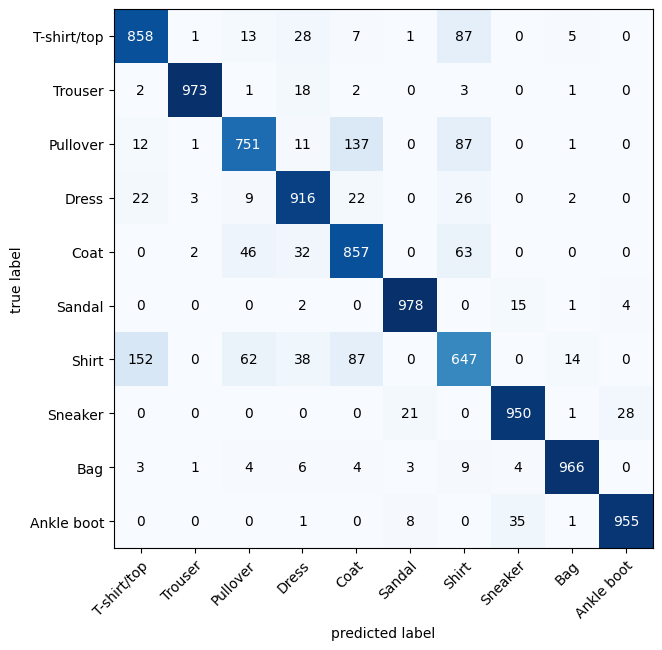

In [52]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

confmat = ConfusionMatrix(num_classes = len(class_names), task = 'multiclass')
confmat_tensor = confmat(preds = y_pred_tensor, target = test_data.targets)

fig, ax = plot_confusion_matrix(
    conf_mat = confmat_tensor.numpy(),
    class_names= class_names,
    figsize = (10, 7)
);